# Introduction

# Emergency Call Data Analysis: Lithuania 112

This notebook performs an in-depth analysis of emergency call data from Lithuania's 112 system. The objective is to uncover patterns, trends, and relationships within emergency incidents to potentially inform resource allocation, policy-making, and public safety initiatives.

The analysis covers several key areas:

1.  **Data Loading and Preprocessing:** Initial steps involve loading the raw data, inspecting its structure, and cleaning it for consistency and usability. This includes handling missing values, standardizing column names, and transforming geographical coordinates.
2.  **Exploratory Data Analysis (EDA):** A comprehensive exploration of incident types, frequencies, and temporal patterns. This section will identify the most common and rare emergency calls, as well as monthly and yearly trends.
3.  **Geospatial Analysis:** Visualization of incident locations to identify hotspots and understand the spatial distribution of emergencies across Lithuania.
4.  **Statistical Analysis:** Application of statistical tests to assess the association between different categorical variables, such as incident type and time (month, year).
5.  **Correlation Analysis for Mixed Data:** Development and application of methods to compute a mixed correlation matrix, allowing us to understand relationships between both numerical and categorical features.
6.  **Clustering:** Identification of dense clusters of incidents using algorithms like DBSCAN to pinpoint areas with high emergency call activity.

Through this multi-faceted approach, we aim to provide valuable insights into the dynamics of emergency services in Lithuania.

## Necessities

In [68]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency



## EDA

In [39]:
df = pd.read_csv('112.csv')
df.head()

,X,Y,ivykio_tipo_kodas,ivykio_id,metai,menuo,aukstesnis_ivykio_tipas,zemesnis_ivykio_tipas,object_id
0,455179,6202578,2.1,8a05b17d59f0,2022,3,BPC-GMP,GMP įvykis,1
1,496996,6088060,2.1,c9ffee4c15df,2022,3,BPC-GMP,GMP įvykis,2
2,396311,6243084,2.1,c349aa73f059,2022,3,BPC-GMP,GMP įvykis,3
3,509278,6113549,2.1,23b71b2f9a07,2022,3,BPC-GMP,GMP įvykis,4
4,323452,6174157,6.1.2,a15a6960d21f,2022,3,Policijos įvykiai,KET pažeidimas,5


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1970925 entries, 0 to 1970924
Data columns (total 9 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   X                        int64 
 1   Y                        int64 
 2   ivykio_tipo_kodas        object
 3   ivykio_id                object
 4   metai                    int64 
 5   menuo                    int64 
 6   aukstesnis_ivykio_tipas  object
 7   zemesnis_ivykio_tipas    object
 8   object_id                int64 
dtypes: int64(5), object(4)
memory usage: 135.3+ MB


Provided data displays that there are overall 1970924 data points with 9 different features including both numerical and categorical data.

### Data Cleansing

In [41]:
df.columns

Index(['X', 'Y', 'ivykio_tipo_kodas', 'ivykio_id', 'metai', 'menuo',
       'aukstesnis_ivykio_tipas', 'zemesnis_ivykio_tipas', 'object_id'],
      dtype='object')

In [42]:
df.head()

,X,Y,ivykio_tipo_kodas,ivykio_id,metai,menuo,aukstesnis_ivykio_tipas,zemesnis_ivykio_tipas,object_id
0,455179,6202578,2.1,8a05b17d59f0,2022,3,BPC-GMP,GMP įvykis,1
1,496996,6088060,2.1,c9ffee4c15df,2022,3,BPC-GMP,GMP įvykis,2
2,396311,6243084,2.1,c349aa73f059,2022,3,BPC-GMP,GMP įvykis,3
3,509278,6113549,2.1,23b71b2f9a07,2022,3,BPC-GMP,GMP įvykis,4
4,323452,6174157,6.1.2,a15a6960d21f,2022,3,Policijos įvykiai,KET pažeidimas,5


In [43]:
# Translation from LT TO ENG
df.rename(columns={'X':'longitude','Y':'latitude', 'aukstesnis_ivykio_tipas':'higher_level_incident_type','zemesnis_ivykio_tipas':'lower_level_incident_type','metai':'year','menuo':'month','ivykio_tipo_kodas':'incident_type_code','ivykio_id': 'incident_id' }, inplace=True)
df.head()

,longitude,latitude,incident_type_code,incident_id,year,month,higher_level_incident_type,lower_level_incident_type,object_id
0,455179,6202578,2.1,8a05b17d59f0,2022,3,BPC-GMP,GMP įvykis,1
1,496996,6088060,2.1,c9ffee4c15df,2022,3,BPC-GMP,GMP įvykis,2
2,396311,6243084,2.1,c349aa73f059,2022,3,BPC-GMP,GMP įvykis,3
3,509278,6113549,2.1,23b71b2f9a07,2022,3,BPC-GMP,GMP įvykis,4
4,323452,6174157,6.1.2,a15a6960d21f,2022,3,Policijos įvykiai,KET pažeidimas,5


In [44]:
df.loc[:, 'higher_level_incident_type'] = df['higher_level_incident_type'].replace({'BPC-GMP':'Emergency Response Center → Ambulance Service','Policijos įvykiai':'Police incidents','Konsultacija':'Consultation','PGT įvykiai':'Fire and Rescue Department incidents','Aplinkosauga':'Environmental protection','BPC TRUKDANTIS':'Obstructing/disrupting the Emergency Response Center','SPEC tarnybos':'Special services','LAKD':'Lithuanian Road Administration','BPC-PGT':'Emergency Response Center → Fire and Rescue','Pagalba 112': '112 assistance','GMP įvykiai':'Ambulance services incidents','Testavimo pratybos': 'Testing exercises / drills', 'POLICIJOS pareigūnų korupcija *': 'Corruption of police officers'})

In [45]:
df.loc[:, 'lower_level_incident_type'] = df['lower_level_incident_type'].replace({
    'GMP įvykis': 'Ambulance incident',
    'KET pažeidimas': 'Traffic violation',
    'Pavojus eismo saugumui': 'Danger to traffic safety',
    'Ekonominės ir verslo tvarkos veikos': 'Economic and business order offenses',
    'Konsultacija': 'Consultation',
    'Turtinė veika anksčiau': 'Previous property crime',
    'eCall': 'eCall',
    'Eismo įvykis': 'Traffic accident',
    'Lavonas': 'Dead body',
    'Neklasifikuoti': 'Unclassified',
    'Rasti ar pamesti daiktai': 'Found or lost items',
    'Kompleksinis įvykis': 'Complex incident',
    'Sprogimas ar sprogimo grėsmė': 'Explosion or explosion threat',
    'Įvairūs viešosios tvarkos pažeidimai': 'Various public order violations',
    'Nusikaltimai asmeniui dabar': 'Crimes against person (current)',
    'Gaisras 0': 'Fire 0',
    'Nusikaltimai asmeniui anksčiau': 'Previous crimes against person',
    'Teisės pažeidimai aplinkosaugos srityje': 'Environmental law violations',
    'BPC TRUKDANTIS': 'Obstructing emergency center',
    'Auto 1': 'Vehicle incident 1',
    'Gelbėjimas': 'Rescue',
    'Smurtas artimoje aplinkoje': 'Domestic violence',
    'Turtinė veika dabar': 'Current property crime',
    'Pagalba specialiosioms tarnyboms': 'Assistance to special services',
    'Įvykiai su laukiniais gyvūnais': 'Wild animal incidents',
    'Pavojus gyvybei': 'Life-threatening danger',
    'Įtartini asmenys': 'Suspicious persons',
    'Gaisras 1': 'Fire 1',
    'Vanduo': 'Water',
    'SPEC tarnybos': 'Special services',
    'Narkotinės medžiagos': 'Narcotic substances',
    'Asmens paieška': 'Missing person search',
    'Žolė': 'Grass fire',
    'Nafta': 'Oil',
    'LAKD': 'Road administration',
    'Gaisras 1AK': 'Fire 1AK',
    'Įvykiai, susiję su policijos veikla': 'Police-related incidents',
    'Įvykiai dėl kurių gali kilti ar kilo pavojus gyventojams ar aplinkai':
        'Incidents dangerous to residents or environment',
    'PGT neklasifikuoti': 'Fire department unclassified',
    'Demerkurizavimas': 'Mercury cleanup',
    'Ginklai, šaudmenys, karo laikų sprogmenys':
        'Weapons, ammunition, wartime explosives',
    'Auto 2': 'Vehicle incident 2',
    'Chemija - Vanduo': 'Chemical - Water',
    'Gaisras 3': 'Fire 3',
    'Gaisras 2': 'Fire 2',
    'Neigiama informacija internete': 'Negative information online',
    'Chemija': 'Chemical incident',
    'Neapykantos kalba ir neapykantos kurstymas':
        'Hate speech and incitement',
    'Žolė (SA)': 'Grass fire (special response)',
    'BPC-GMP': 'Emergency center - ambulance',
    'Gaisras (SA)': 'Fire (special response)',
    'Gelbėjimo darbai (SA)': 'Rescue operations (special response)',
    'PGT pratybos': 'Fire department exercises',
    'Aukštis': 'Height rescue',
    'Demerkurizavimas (SA)': 'Mercury cleanup (special response)',
    'Pagalba 112': '112 assistance',
    'PGT neklasifikuoti (SA)': 'Fire department unclassified (special response)',
    'Pratybos (SA)': 'Exercises (special response)',
    'Aukštis AK': 'Height rescue AK',
    'Kiti psichikos ir elgesio sutrikimai':
        'Other mental and behavioral disorders',
    'Pervežimas': 'Transport',
    'Ūmus kraujotakos sutrikimas': 'Acute circulatory disorder',
    'Dusulys': 'Shortness of breath',
    'Kūno temperatūros pokyčiai': 'Body temperature changes',
    'Gausus vėmimas, viduriavimas': 'Severe vomiting or diarrhea',
    'Širdies veiklos sutrikimai': 'Heart disorders',
    'Miršta, nekvėpuoja, mėlynuoja': 'Dying, not breathing, turning blue',
    'Budėjimas renginyje, laidotuvėse':
        'Standby at event or funeral',
    'Įvairios sunkios traumos': 'Various severe injuries',
    'Šlapimo susilaikymas': 'Urinary retention',
    'Sąmonės sutrikimas': 'Consciousness disorder',
    'Pilvo skausmas': 'Abdominal pain',
    'Smurtas/prievartavimas': 'Violence/rape',
    'Skubus pervežimas': 'Urgent transport',
    'Neramumas / susijaudinimas': 'Restlessness/agitation',
    'Epideminė situacija': 'Epidemic situation',
    'Transporto priemonių avarija': 'Vehicle accident',
    'Insultas': 'Stroke',
    'Traukuliai': 'Seizures',
    'Dubliuotas kvietimas': 'Duplicate call',
    'Perduota kitoms tarnyboms': 'Transferred to other services',
    'Kraujavimas (netrauminis)': 'Non-traumatic bleeding',
    'Stiprus skausmas': 'Severe pain',
    'Skambutis ne GMP tikslais': 'Call not related to ambulance services',
    'Ūmi alerginė reakcija': 'Acute allergic reaction',
    'Galvos skausmas': 'Headache',
    'Ekstremalusis įvykis': 'Extreme incident',
    'Kvietimas pas vaiką iki 1 metų amžiaus':
        'Call for child under 1 year old',
    'Perimtas insultas': 'Transferred stroke case',
    'Krūtinės skausmas': 'Chest pain',
    'Nugaros skausmas': 'Back pain',
    'Gulintis_žmogus': 'Person lying down',
    'Ūmus apsinuodijimas': 'Acute poisoning',
    'Diabeto komplikacijos': 'Diabetes complications',
    'Bandymas nusižudyti (savižudybės pavojus)':
        'Suicide attempt (suicide risk)',
    'Nenormalus kraujospūdis': 'Abnormal blood pressure',
    'Gaisras pastate, nežinoma situacija':
        'Building fire, unknown situation',
    'Sunkūs nudegimai': 'Severe burns',
    'Atsisakė/Atsakytas': 'Refused/responded',
    'Įtariamas vidinis kraujavimas': 'Suspected internal bleeding',
    'Pagalba kitoms tarnyboms': 'Assistance to other services',
    'Sąmonės netekimas': 'Loss of consciousness',
    'GMP kvietimas_Panevėžys': 'Ambulance call - Panevėžys',
    'Lengvesnio ir vidutinio sunkumo traumos':
        'Minor and moderate injuries',
    'Lėtinių ligų paūmėjimas': 'Chronic disease exacerbation',
    'Mirties konstatavimas': 'Confirmation of death',
    'Komercinis pervežimas': 'Commercial transport',
    'Užspringimas': 'Choking',
    'Parezė/paralyžius': 'Paresis/paralysis',
    'Nėštumo komplikacijos': 'Pregnancy complications',
    'Akių sužalojimai': 'Eye injuries',
    'Skambinančiajam reikalaujant': 'At caller request',
    'Perimtas infarktas': 'Transferred heart attack case',
    'Gyvūnų įkandimai': 'Animal bites',
    'Viešosios tvarkos pažeidimai': 'Public order violations',
    'Chemija (SA)': 'Chemical incident (special response)',
    'Žaibo ir elektros sukelti pažeidimai':
        'Lightning and electricity injuries',
    'SPT': 'Special services',
    'Įvairios lokalizacijos svetimkūniai':
        'Foreign bodies in various locations',
    'Kritimai iš aukščio': 'Falls from height',
    'Rinkimų tvarkos pažeidimai': 'Election law violations',
    'Alerginė reakcija': 'Allergic reaction',
    'Gaisras, kurio metu nukentėjo žmonės':
        'Fire with injured people',
    'Gyvūnų įkandimai (nežymūs), įdrėskimai, apseilėjimai':
        'Minor animal bites, scratches, saliva exposure',
    'Perimta politrauma': 'Transferred polytrauma',
    'Testavimo pratybos': 'Testing exercises',
    'Komplikacijos po gimdymo': 'Postpartum complications',
    'Nušalimai': 'Frostbite',
    'Pasikorimas ir pasismaugimas': 'Hanging and strangulation',
    'Ūmus regėjimo sutrikimas, apakimas':
        'Acute vision disorder, blindness',
    'Gaisras 4': 'Fire 4',
    'Skendimas': 'Drowning',
    'POLICIJOS pareigūnų korupcija *': 'Police officer corruption',
    'Gelbėjimo darbai': 'Rescue operations',
    'Aplinkosauga': 'Environmental protection',
    'Saulės, šilumos smūgis': 'Heatstroke/sunstroke',
    'Valstybės tarnautojų korupcija':
        'Public servant corruption',
    'GMP konsultacija': 'Ambulance consultation',
    'Nežymūs nušalimai, nudegimai':
        'Minor frostbite and burns',
    'ATOMINĖ': 'Nuclear incident',
    'Turtinė veika': 'Property crime',
    'GMP įvykiai': 'Ambulance incidents',
    'Kaliningrado tranzitas': 'Kaliningrad transit',
    'Gaisrai': 'Fires',
    'Kiti įvykiai': 'Other incidents',
    'Griūtis': 'Collapse',
    'Pagalbos tarnybų pareigūnų prašymas':
        'Request from emergency service officers',
    'Eismo saugumas': 'Traffic safety',
    'Gaisras 5': 'Fire 5',
    'Nėštumas, gimdymas': 'Pregnancy and childbirth',
    'Radiacija': 'Radiation',
    '116000': '116000 hotline',
    'Ginklai, šaudmenys, sprogmenys':
        'Weapons, ammunition, explosives',
    'Nusikaltimai asmeniui': 'Crimes against person'
})

Since the dataset uses Lithuania's national coordinate system, the coordinates were transformed into the international WGS84 (EPSG:4326) standard to enable map-based visualisation.

In [46]:
geometry = [Point(xy) for xy in zip(df['longitude'],df['latitude'])]
df = gpd.GeoDataFrame(df,geometry=geometry,crs='EPSG:3346')
# Transform to WGS84 (EPSG:4326)
df = df.to_crs(epsg=4326)
df['longitude']= df.geometry.x
df['latitude'] = df.geometry.y

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df[df.isna().any(axis=1)]

,longitude,latitude,incident_type_code,incident_id,year,month,higher_level_incident_type,lower_level_incident_type,object_id,geometry
796703,21.160301,55.720911,NaN,bd7fd27e88e1,2023,4,NaN,NaN,796704,POINT (21.1603 55.72091)
1254657,22.330646,56.344855,NaN,a4317285e92d,2023,5,NaN,NaN,1254658,POINT (22.33065 56.34485)
1255859,23.864662,54.646945,NaN,ddb99be79bed,2023,5,NaN,NaN,1255860,POINT (23.86466 54.64695)


In [49]:
df.dropna(inplace=True)
df.isna().sum()

,0
longitude,0
latitude,0
incident_type_code,0
incident_id,0
year,0
month,0
higher_level_incident_type,0
lower_level_incident_type,0
object_id,0
geometry,0


### Core Features

In [50]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1970922 entries, 0 to 1970924
Data columns (total 10 columns):
 #   Column                      Dtype   
---  ------                      -----   
 0   longitude                   float64 
 1   latitude                    float64 
 2   incident_type_code          object  
 3   incident_id                 object  
 4   year                        int64   
 5   month                       int64   
 6   higher_level_incident_type  object  
 7   lower_level_incident_type   object  
 8   object_id                   int64   
 9   geometry                    geometry
dtypes: float64(2), geometry(1), int64(3), object(4)
memory usage: 165.4+ MB


> ### **longitude**
This feature is represents geographic coordinate of east-west approximate position of the accident.

> ### **latitude**
Property illustrated geographic coordinate representing the north-south position of the incident's approximate location.

In [51]:
df_sample = df.sample(n=10000, random_state=42)
fig_sample = px.scatter_mapbox(
    df_sample,
    lat="latitude",
    lon="longitude",
    color="higher_level_incident_type",
    hover_data=['year', 'higher_level_incident_type', 'lower_level_incident_type'],
    zoom=6,
    height=900,
    width=900,
    title="Sample of Incident Locations by Higher-Level Incident Type"
)

fig_sample.update_layout(
    mapbox_style="open-street-map"
)

fig_sample.show()

> ### **higher_level_incident_type**
Attribute that explicates the general category of the emergency incident.

In [52]:
print(f'There are {df.higher_level_incident_type.nunique()} diverse categories of accidents.')

There are 15 diverse categories of accidents.


In [53]:
df[['higher_level_incident_type']].value_counts()

,count
higher_level_incident_type,
Police incidents,836362
Emergency Response Center → Ambulance Service,817428
Ambulance services incidents,193876
Fire and Rescue Department incidents,49101
Consultation,28332
Environmental protection,26482
Obstructing/disrupting the Emergency Response Center,8442
Special services,5396
Lithuanian Road Administration,2760


### Conclusions from Higher-Level Incident Type Counts

Based on the frequency of each `higher_level_incident_type`, here are some key conclusions:

1.  **Dominant Incident Types:** `Police incidents` and `Emergency Response Center → Ambulance Service` are the most prevalent categories, each accounting for over 800,000 occurrences. These two types represent the overwhelming majority of reported incidents, indicating the primary workload for emergency services.

2.  **Next Tier of Significance:** `Ambulance services incidents`, `Fire and Rescue Department incidents`, `Consultation`, and `Environmental protection` comprise the next level of incident frequency. While significant, their counts are considerably lower than the top two.

3.  **Rare Occurrences:** Categories like `112 assistance`, `Corruption of police officers`, and `116000` are extremely rare, appearing with very low single-digit counts. `Testing exercises / drills` also falls into this low-frequency group, suggesting these are either highly specialized, infrequent, or simulated events.

> ### **lower_level_incident_type**
Characteristic that exemplifies the specific type of emergency incident within a broader incident category.

In [54]:
print(f'There are {df.lower_level_incident_type.nunique()} subcategories of incidents in this dataset.')

There are 153 subcategories of incidents in this dataset.


In [55]:
df[['lower_level_incident_type']].value_counts()

,count
lower_level_incident_type,
Ambulance incident,744798
Traffic violation,189390
Various public order violations,162397
Previous property crime,87722
Domestic violence,83206
...,...
Fires,2
116000 hotline,1
Crimes against person,1


### Conclusions about Lower-Level Incident Types

Based on the frequency of `lower_level_incident_type`, here are some key conclusions:

1.  **Dominant Subcategory**: `Ambulance incident` is by far the most frequent specific type of incident, accounting for a massive number of calls (over 740,000).
2.  **Key Police-Related Subcategories**: Following ambulance calls, several police-related subcategories are prominent, including `Traffic violation`, `Various public order violations`, `Previous property crime`, and `Domestic violence`. These indicate areas requiring significant police resources.
3.  **Broad Spectrum of Incidents**: The dataset contains a very wide range of specific incident types (153 unique subcategories), reflecting the diverse nature of emergencies that require response.
4.  **Extremely Rare Subcategories**: Similar to the higher-level incidents, many lower-level incident types are extremely rare, appearing with only 1, 2, 3, or 4 occurrences. These include very specific or unusual events like `Fires`, `116000 hotline`, `Crimes against person`, `Other incidents`, and `Pregnancy and childbirth`. This highlights highly specialized or infrequent emergency situations.

> ### **incident_type_code**
Given trait is a unique hierchical classification code used to identify the specific type of emergency incident with the BPC classification system.

In [56]:
print(f'There are {df.incident_type_code.nunique()} distinct emergency codes in the dataset.')

There are 154 distinct emergency codes in the dataset.


In [57]:
the_most_popular_emergency_codes = df[['higher_level_incident_type','lower_level_incident_type','incident_type_code']].value_counts()[:10]

In [58]:
the_most_popular_emergency_codes

higher_level_incident_type                     lower_level_incident_type        incident_type_code
Emergency Response Center → Ambulance Service  Ambulance incident               2.1                   744798
Police incidents                               Traffic violation                6.1.2                 189390
                                               Various public order violations  6.7.1                 162397
                                               Previous property crime          6.6.1                  87722
                                               Domestic violence                6.5.4                  83206
Emergency Response Center → Ambulance Service  Complex incident                 2.2                    72584
Police incidents                               Unclassified                     6.4.9                  59263
                                               Danger to traffic safety         6.1.3                  44318
                                               Crimes against person (current)  6.5.2                  33912
                                               Current property crime           6.6.2                  30826
Name: count, dtype: int64

In [59]:
fig = px.bar(the_most_popular_emergency_codes.reset_index(),x='higher_level_incident_type',y='count',color = 'lower_level_incident_type',title='Most popular emergency calls frequency')
fig.show()

In [60]:
the_least_popular_emergency_codes = df[['higher_level_incident_type','lower_level_incident_type','incident_type_code']].value_counts()[-10:]
the_least_popular_emergency_codes

higher_level_incident_type            lower_level_incident_type        incident_type_code
Fire and Rescue Department incidents  Fire 5                           5.3.7                 4
Ambulance services incidents          Ambulance incidents              4                     3
Police incidents                      Weapons, ammunition, explosives  6.2                   3
Environmental protection              Environmental protection         1                     3
Fire and Rescue Department incidents  Radiation                        5.2.5                 2
                                      Fires                            5.3                   2
116000                                116000 hotline                   12                    1
Ambulance services incidents          Pregnancy and childbirth         4.5                   1
Police incidents                      Crimes against person            6.5                   1
                                      Other incidents                  6.4                   1
Name: count, dtype: int64

The most popular emergency codes are:

In [61]:
px.bar(the_least_popular_emergency_codes.reset_index(),x='higher_level_incident_type',y='count',color='lower_level_incident_type',title='Least popular emergency calls frequency')

### Most Popular Emergency Incidents

1.  **Dominance of Ambulance Service Calls:** The most frequent emergency incidents are significantly related to `Emergency Response Center → Ambulance Service`, with `Ambulance incident` (code 2.1) being the most common by a large margin (over 250,000 occurrences).
2.  **Key Police Incident Types:** Among `Police incidents`, `Traffic violation` (code 6.1.2), `Various public order violations` (code 6.7.1), and `Previous property crime` (code 6.6.1) are the most frequent.
3.  **High-Frequency Categories:** The top 10 most popular emergency codes are dominated by core ambulance and police response categories, indicating the primary workload areas for emergency services.

### Least Popular Emergency Incidents

1.  **Extremely Rare Events:** The least popular emergency codes represent very rare occurrences, often with single-digit counts. These include highly specific or unusual incidents like `Pregnancy and childbirth`, `Other accidents`, and various specialized medical conditions.
2.  **Specialized/Anomalous Categories:** These low-frequency incidents often point to highly specialized responses or events that are thankfully uncommon.

### Reasoning Behind Incident Category Frequencies

The varying frequencies of incident categories are due to a combination of factors related to the nature of the incidents themselves, public behavior, and the structure of emergency services. Here's a breakdown of the reasoning:

### Why Some Categories "Win" (Are Highly Frequent):

1.  **Commonplace Occurrences**: Many high-frequency incidents are simply part of daily life. For example, `Ambulance incident` often covers a wide range of medical issues, from minor ailments to serious emergencies, which are statistically more likely to occur than, say, a nuclear incident. `Traffic violations` are also a frequent occurrence in any populated area with vehicles.
2.  **Broad Definitions**: Some categories, particularly `Ambulance incident` and `Police incidents`, act as umbrella terms for a multitude of specific events. This broadness naturally leads to higher counts as many different scenarios can fall under these general classifications.
3.  **Immediate Public Need**: Incidents like medical emergencies (`Ambulance Service`) and immediate threats to public order/safety (`Police incidents`) require urgent attention, making them the most common reasons for people to contact emergency services.
4.  **Accessibility and Awareness**: The public is generally well aware of when to call for an ambulance or police, and these services are the primary points of contact for a vast array of urgent situations.

### Why Some Categories "Do Not Win" (Are Infrequent):

1.  **Rarity of the Event**: Some incidents are inherently rare. Catastrophic events like `Radiation`, major `Fires` (especially higher classifications like `Fire 5`), or specific types of `Corruption` are thankfully not common occurrences in society.
2.  **Specialized Nature**: Certain categories might represent highly specialized or niche situations that occur infrequently. For instance, `116000 hotline` refers to a specific missing children hotline, which, while crucial, receives fewer calls than general emergency services.
3.  **Severity vs. Frequency**: While incidents like `Weapons, ammunition, explosives` or `Crimes against person` are extremely serious, their occurrence is (fortunately) much lower than more common issues like traffic violations or minor medical calls.
4.  **Alternative Reporting Channels**: Some specific incidents might have alternative, non-112 reporting mechanisms. For example, while environmental protection is important, many non-urgent environmental concerns might be reported directly to a specific environmental agency rather than the general emergency number.
5.  **Simulated/Training Events**: Categories like `Testing exercises / drills` are by definition infrequent, as they are controlled simulations rather than real-world emergencies.

In summary, the distribution reflects the day-to-day realities and risks faced by the population, with common, broad-scope incidents dominating the call volume, while rare, specialized, or catastrophic events occur with much lower frequency.

> ### **geometry**
Variable that elucidates the geospatial point object representing the incident's approximate location after coordinate system transformation.

> ### **year, month**
These descriptions are the calendar year, month during which the emergency incident has occured.

In [62]:
years = sorted(df.year.unique())
print(f'The unique years mentioned in the dataset: {[int(year) for year in years]}')

The unique years mentioned in the dataset: [2021, 2022, 2023]


In [63]:
df['year_month'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-' + df['month'].astype(int).astype(str))
monthly_yearly_counts = df['year_month'].value_counts().reset_index()
monthly_yearly_counts.columns = ['year_month','count']
monthly_yearly_counts = monthly_yearly_counts.sort_values(by='year_month')
fig = px.line(monthly_yearly_counts,x='year_month',y='count')
fig

### Conclusions about Year and Month Data

Based on the analysis of the `year` and `month` data, several key observations can be made:

1. **Data Coverage:**
   The dataset spans from September 2021 to June 2023.

2. **Yearly Trends:**

   * **2022** recorded the highest number of incidents.
   * **2023** shows a lower total count compared to 2022; however, the data for 2023 is incomplete, covering only up to June.

3. **Monthly Patterns (Overall):**

   * When considering all years combined, some months tend to have higher incident counts (such as March, April, and May), while others show lower counts (such as February and September).
   * This suggests possible seasonal variation in incident occurrence.

4. **Combined Year–Month Trends:**

   * The `year_month` analysis shows a rise in incidents towards the end of 2021, followed by consistently high but fluctuating activity throughout most of 2022.
   * A substantial drop is observed in October 2022, where incident counts decrease sharply compared to surrounding months. This anomaly is unlikely to represent real-world conditions and most likely indicates missing or incomplete data, a data collection issue, or preprocessing/filtering errors.
   * The beginning of 2023 continues to show relatively high activity levels, with a slight decline observed by June 2023.


### Possible Reasons for Fluctuations Over Time

Fluctuations in incident counts over time may be caused by several factors, including:

1. **Seasonality:** Weather changes, daylight hours, and seasonal activities can affect incident rates.
2. **Holidays and Events:** Public holidays, festivals, and large gatherings may increase or decrease incidents.
3. **Socio-economic Factors:** Economic conditions and social trends can influence incident patterns over time.
4. **Reporting or System Changes:** Changes in reporting behavior or data collection methods may impact recorded counts.
5. **Specific Major Events:** Accidents, disasters, or protests can create temporary spikes.
6. **Incomplete Data:** Recent years may appear lower if data collection is not yet complete.


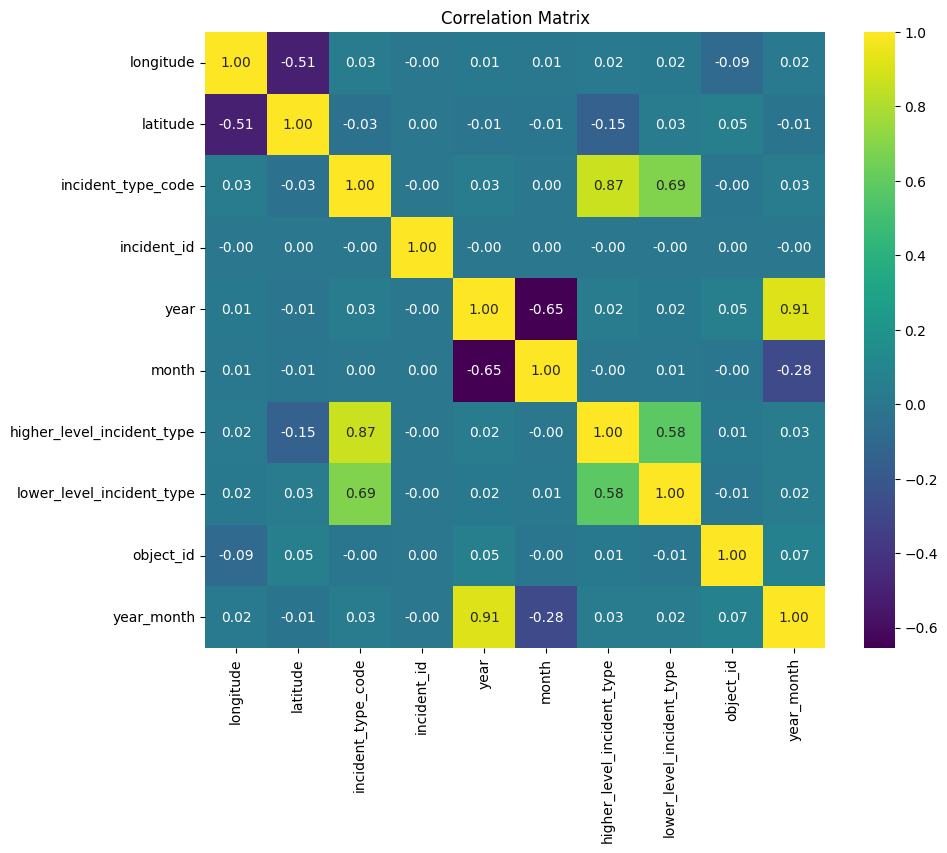

In [64]:
df_corr = df.copy()

# Dropping the 'geometry' column before calculating correlations
df_corr = df_corr.drop(columns=['geometry'], errors='ignore')

# Converting categorical columns to numeric codes
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

corr_matrix = df_corr.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# Statistical Tests

## 1.  month VS higher_level_incident_type
## Chi-square Test

**Null Hypothesis**: there is no relationship between the month and the occured type of accident.

**Alternative Hypothesis**: there is a connection between the month and the sort of incident happened.

In [69]:
contingency_table = pd.crosstab(df.month,df.higher_level_incident_type)
stat,p,dof,expected = chi2_contingency(contingency_table)
print(f'Chi-square statistic: {stat}')
print(f'Degrees of freedom: {dof}')
print(f'p-value:{p:.6f}')


Chi-square statistic: 9487.654603284358
Degrees of freedom: 154
p-value:0.000000


**Checking effect size**:
Cramer's test allows to test on HOW POWERFUL the relationship is.

In [70]:
n = contingency_table.sum().sum()
rows,cols = contingency_table.shape
cramers_v = np.sqrt(stat /(n *(min(rows,cols)-1)))
print(f'{cramers_v:.4f}')

0.0209


| Cramér’s V | Strength  |
| ---------- | --------- |
| 0.00–0.10  | very weak |
| 0.10–0.30  | weak      |
| 0.30–0.50  | moderate  |
| >0.50      | strong    |


Consequently, even though the p-value is less than 0.05 and the null hypothesis can be rejected, Cramér’s V statistic of 0.0209 indicates a very weak association between the variables.

**This means that although there is statistical evidence of an association between accidents and month, the relationship is very weak in practical terms.**